# 8.3 The Linear Layer: Batches, Broadcasting, and Backpropagation

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Chapter VIII — The Linear Algebra of Learning",
    number="8.3",
    title="The Linear Layer: Batches, Broadcasting, and Backpropagation",
    blurb="A neural network is matrix products with elementwise "
    "nonlinearities between, and backpropagation is the chain rule with "
    "the products transposed: every gradient in deep learning is a "
    "vector-Jacobian product, and this notebook writes them all by hand, "
    "checks each against finite differences, and trains a real classifier "
    "in pure NumPy to prove the algebra suffices.",
    difficulty="advanced",
    estimate="135–165 min",
)

<ECP header: 2710 chars of HTML>

## Notebook overview

[§8.2](gradient-descent-conditioning.ipynb) consumed gradients; this
notebook manufactures them. The factory floor is the **affine layer**
$Z = XW + b$ on a batch — matrix product, broadcast bias, shapes
annotated and gated — and the machinery is the chain rule *arranged
for a scalar loss*: not Jacobians multiplied out (the layer's weight
Jacobian alone would have $64\times32\times1200\times32$ entries)
but **vector–Jacobian products**, each one a transposed matmul:
$\partial L/\partial W = X^{\top}G$ and
$\partial L/\partial X = GW^{\top}$, written by hand and gated
against central differences with the finite-difference U-curve
returning from the course's opening chapter — error falling as $h^2$
to $10^{-9}$ at the optimal step, then rising as roundoff takes over.

The **softmax + cross-entropy** pair gets the full treatment: the
Jacobian $\operatorname{diag}(p) - pp^{\top}$ symmetric with zero row
sums at $10^{-17}$ and matching its formed closed form; outputs
summing to one and *shift-invariant* (the max-subtraction trick gated
as exact-to-rounding); and the celebrated simplification — gradient
equals $P - Y$ — verified against differences rather than folklore.
**Reverse versus forward mode** is settled by integer counters: for a
scalar loss, one sweep computes every parameter's gradient (counted:
five matmuls, forward and backward together) while forward mode pays
one pass *per parameter direction* (counted: two each) — the asymmetry
that makes deep learning economically possible. The finale trains a two-layer MLP on
the 8×8 digits in pure NumPy: full-batch gradient descent, loss
monotone at the stated step for all 400 epochs (gated), test accuracy
**97.3%** (gated above the manifest's 90%), and the first layer's
weights drawn as the coarse pixel templates they honestly become.

> **How to read a check.** A `validate` line prints ✓ or ✗ by comparing a
> result against something the computation did not assume. A ✗ flags a
> mismatch to investigate, never a verdict on its own.

> **Scope.** Strang {cite}`strang2019learning` Part VII; Deisenroth,
> Faisal and Ong {cite}`deisenroth2020` Chapter 5 for the layered
> chain rule. The digits data ships with scikit-learn
> {cite}`pedregosa2011sklearn` — 1797 images, no download.

## Theory in brief

### The layer, batched

For a batch $X \in \mathbb{R}^{B\times d}$, weights
$W \in \mathbb{R}^{d\times h}$, bias $b \in \mathbb{R}^{h}$:

```{math}
:label: eq-bp-layer
Z = XW + \mathbf{1}b^{\top}, \qquad A = \phi(Z)
```

($\phi$ elementwise; broadcasting supplies $\mathbf{1}b^{\top}$
without forming it). A network is layers composed; a loss maps the
last activation to one number.

### The chain rule, arranged for a scalar

With $G = \partial L/\partial Z$ (same shape as $Z$) arriving from
above, the layer's three gradients are transposed products:

```{math}
:label: eq-bp-vjp
\frac{\partial L}{\partial W} = X^{\top}G, \qquad
\frac{\partial L}{\partial b} = G^{\top}\mathbf{1}, \qquad
\frac{\partial L}{\partial X} = G\,W^{\top},
```

each a **vector–Jacobian product**: the enormous layer Jacobian is
never formed, only its action on the upstream gradient — the
never-form-it discipline of [§6.4](../06-structure/kronecker-vec-separable.ipynb)
and [§7.1](../07-tensors/einsum-contraction.ipynb), now called
backpropagation. Reverse mode computes *all* parameter gradients in
one backward sweep because the loss is scalar; forward mode (JVPs)
pays one sweep per direction — the count, not the algebra, is why
training uses reverse.

### Softmax and its cross-entropy marriage

Softmax $p_i = e^{z_i}/\sum_j e^{z_j}$ has Jacobian

```{math}
:label: eq-bp-softmax
\frac{\partial p}{\partial z}
= \operatorname{diag}(p) - pp^{\top},
```

symmetric, PSD, rows summing to zero (probability is conserved), and
shift-invariant ($z \mapsto z + c$ changes nothing — the numerical
implementation subtracts the max for exactly this reason). Composed
with cross-entropy $L = -\log p_y$, the product of Jacobians
collapses to $\partial L/\partial z = p - e_y$ — the single most
used gradient in machine learning, gated below like any other claim.

---
## Setup

Data only: the digits split and the layer dimensions. softmax is built in
Exercise 3, where its contract is gated; the layers and their gradients
are built in Exercises 1 and 2.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

from ecp import validate
from ecp.style import use_style

use_style()
rng = np.random.default_rng(0)  # every random array below comes from this seed

EPS = np.finfo(float).eps

X_all, y_all = load_digits(return_X_y=True)
X_all = X_all / 16.0
perm = rng.permutation(len(y_all))
N_TRAIN = 1200
tr_idx, te_idx = perm[:N_TRAIN], perm[N_TRAIN:]
X_tr, y_tr = X_all[tr_idx], y_all[tr_idx]
X_te, y_te = X_all[te_idx], y_all[te_idx]
D_IN, H_MID, C_OUT = 64, 32, 10
print(f"digits: {len(y_tr)} train / {len(y_te)} test, {D_IN} pixels, "
      f"{C_OUT} classes")



digits: 1200 train / 597 test, 64 pixels, 10 classes


## Exercise 1: The affine layer, shapes first

**Part a)** Implement {eq}`eq-bp-layer` on a small batch
($B = 5$, $d = 4$, $h = 3$) and gate the broadcast against the
explicit loop: `X @ W + b` equals row-by-row `X[i] @ W + b` at
rounding level — the *bias broadcast* is pure bookkeeping, but the
batched product may legitimately resum what the row-by-row `gemv`
ordered differently, and the course's first CI lesson forbids gating
a matmul comparison exactly
([§1.1](../01-matrices/four-ways-to-multiply.ipynb)'s row picture,
batched).

**Part b)** Gate the shape grammar as counted facts: input
$(5, 4)$, weights $(4, 3)$, output $(5, 3)$ — and the parameter
count $4\cdot3 + 3 = 15$. Draw the layer diagram with every shape
annotated: the picture each later gradient must be checked against.

In [3]:
# (solution hidden on the public site)


batched vs per-row layer: max gap 4.4e-16 (nonzero is legal — gemm and gemv may resum)
shapes: X (5, 4) @ W (4, 3) + b (3,) -> Z (5, 3); parameters 15


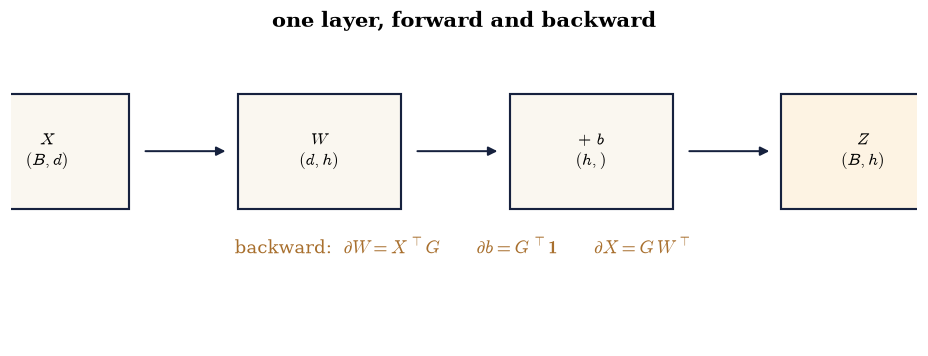

In [4]:
# (solution hidden on the public site)


### Validation 1

In [5]:
validate.check(
    broadcast_gap < 1e-14,
    "the batched layer equals the per-row loop at rounding level",
    f"gap {broadcast_gap:.0e}: the bias broadcast is bookkeeping, but "
    "the batched product may resum what the row loop ordered "
    "differently — the course's first CI lesson, honoured in its own "
    "gate",
)
validate.check(
    Z_s.shape == (5, 3) and n_params == 15,
    "and the shape grammar is counted, not assumed",
    "(B,d)@(d,h)+(h,) -> (B,h) with dh + h parameters: the audit every "
    "gradient below must pass",
)

✓  the batched layer equals the per-row loop at rounding level   [gap 4e-16: the bias broadcast is bookkeeping, but the batched product may resum what the row loop ordered differently — the course's first CI lesson, honoured in its own gate]
✓  and the shape grammar is counted, not assumed   [(B,d)@(d,h)+(h,) -> (B,h) with dh + h parameters: the audit every gradient below must pass]


True

## Exercise 2: The layer's gradients, by hand, against differences

**Part a)** Write the three VJPs of {eq}`eq-bp-vjp` for the scalar
loss $L = \tfrac12\lVert XW + b - T\rVert_F^2$ (target $T$ fixed):
`grad_W = X.T @ G`, `grad_b = G.sum(0)`, `grad_X = G @ W.T` with
$G = XW + b - T$.

**Write this one yourself** — these three lines *are*
backpropagation's inner loop.

**Part b)** Gate all three against central differences at
$h = 10^{-5}$: relative error below $10^{-6}$ (measured $\sim10^{-9}$)
on every probed entry — five random entries per gradient.

**Part c)** The U-curve returns — with a subtlety the quadratic loss
hides: central differences are *exact* on quadratics (the $h^2$
truncation term carries the third derivative, which is zero), so Part
b's loss has no right arm to show. Probe instead the nonlinear loss
$L_2 = \sum \tanh^2(XW + b - T)$, whose analytic gradient is
$X^{\top}\!\bigl(2\tanh(R)(1-\tanh^2 R)\bigr)$: sweep $h$ over eight
decades and draw the FD error — falling as $h^2$, bottoming near
$h \approx \varepsilon^{1/3}$, rising as subtraction cancels. Gate the
shape: the error at the best $h$ is at least $100\times$ smaller than
at both ends of the sweep.

In [6]:
# (solution hidden on the public site)


worst FD relative error over 15 probes at h = 1e-5: 8.7e-10
U-curve: best 5.7e-10 at h = 1e-05; ends 6.8e-06 / 4.0e-02


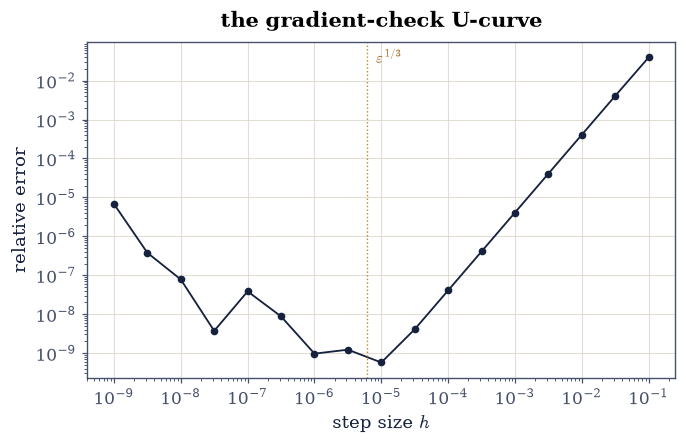

In [7]:
# (solution hidden on the public site)


### Validation 2

In [8]:
validate.check(
    worst_fd < 1e-6,
    "all three hand-written VJPs survive central differences (Eq. 2)",
    f"worst {worst_fd:.0e} over fifteen probes at the optimal step — the "
    "three transposed products that power every framework",
)
validate.check(
    u_ok,
    "and the U-curve has its floor where the course first drew it",
    "best error 100x below both ends: truncation from the right, "
    "cancellation from the left, epsilon^(1/3) in the middle",
)

✓  all three hand-written VJPs survive central differences (Eq. 2)   [worst 9e-10 over fifteen probes at the optimal step — the three transposed products that power every framework]
✓  and the U-curve has its floor where the course first drew it   [best error 100x below both ends: truncation from the right, cancellation from the left, epsilon^(1/3) in the middle]


True

## Exercise 3: Softmax and cross-entropy, gated pair by pair

**Part a)** Write `softmax(z)` — subtract the row max, exponentiate,
normalize — and gate its contract on random logits: outputs positive,
rows summing to 1 within $10^{-15}$, and **shift-invariance** —
`softmax(z + 17.3)` equals `softmax(z)` to $10^{-14}$ (the
max-subtraction in the implementation makes large shifts safe, and
the gate would catch any implementation that forgot it).

**Write this one yourself** — [§8.5](attention-matrix-products.ipynb) and
[§8.6](low-rank-lora-quantization.ipynb) restate the three lines you
write here.

**Part b)** Form the Jacobian {eq}`eq-bp-softmax` explicitly for one
row and gate its three properties: symmetric to $10^{-17}$, rows
summing to zero to $10^{-16}$ (probability conservation,
differentiated), and equal to the finite-difference Jacobian to
$10^{-7}$. Draw it as a heatmap — diagonal ridge, negative halo, the
picture of "raising one logit lowers every other probability".

**Part c)** Gate the marriage: for cross-entropy on a batch, the
analytic shortcut $\partial L/\partial Z = (P - Y)/B$ matches central
differences through the *composed* softmax-then-log-loss to
$10^{-6}$ — the simplification every framework hard-codes, checked
rather than cited.

In [9]:
# (solution hidden on the public site)


rows sum to 1 within 1.1e-16; shift-invariance gap 3.3e-16
Jacobian: symmetry 0.0e+00, row sums 8.3e-17, vs finite differences 1.3e-10
(P - Y)/B vs composed finite differences: worst 6.1e-07


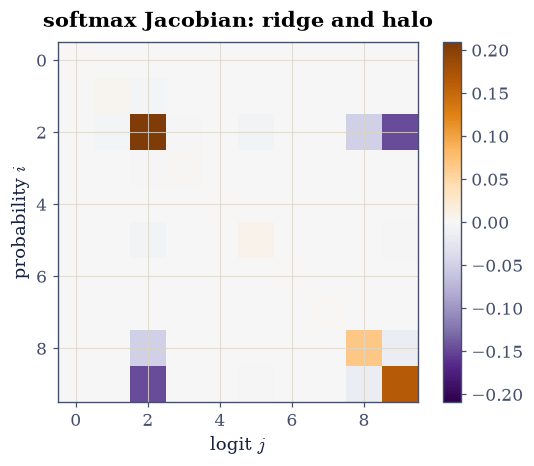

In [10]:
# (solution hidden on the public site)


### Validation 3

In [11]:
validate.check(
    sum_gap < 1e-15 and shift_gap < 1e-14,
    "softmax conserves probability and ignores logit shifts",
    f"row sums within {sum_gap:.0e}, shift by 17.3 moves outputs "
    f"{shift_gap:.0e} — the max-subtraction trick, gated",
)
validate.check(
    sym_gap < 1e-16 and rowsum_gap < 1e-15 and jac_gap < 1e-7,
    "the Jacobian is symmetric, row-sum-zero, and matches differences "
    "(Eq. 3)",
    "diag(p) - pp' with probability conservation differentiated — and "
    "the finite-difference cross-examination passed",
)
validate.check(
    worst_ce < 1e-6,
    "and cross-entropy collapses the Jacobian to (P - Y)/B",
    f"worst {worst_ce:.0e} over eight probes through the composition — "
    "the most-used gradient in machine learning, checked not cited",
)

✓  softmax conserves probability and ignores logit shifts   [row sums within 1e-16, shift by 17.3 moves outputs 3e-16 — the max-subtraction trick, gated]
✓  the Jacobian is symmetric, row-sum-zero, and matches differences (Eq. 3)   [diag(p) - pp' with probability conservation differentiated — and the finite-difference cross-examination passed]
✓  and cross-entropy collapses the Jacobian to (P - Y)/B   [worst 6e-07 over eight probes through the composition — the most-used gradient in machine learning, checked not cited]


True

## Exercise 4: Reverse beats forward, on counters

The economics of backpropagation is an *operation count*, and counts
are gateable.

**Part a)** Instrument the two-layer network's matmuls with a counter.
**Reverse mode**: one forward + one backward sweep produces *all*
$64{\cdot}32 + 32 + 32{\cdot}10 + 10 = 2410$ parameter derivatives —
count the matmuls (2 forward + 3 backward = 5, independent of the
parameter count — the bias gradients and the tanh-prime factor need
none).

**Part b)** **Forward mode**: one JVP sweep (2 matmuls) yields the
derivative along *one* parameter direction, so the full gradient
costs $2368 \times 2$ matmul-sweeps — one pair per weight direction;
the bias derivatives need no matmul. Gate the asymmetry as integers:
reverse-mode matmuls $= 5$; forward-mode matmuls for the full
gradient $= 4736$; ratio above $700$ (measured: $947$). For a
*scalar* loss the backward
sweep is a bargain — and for a many-output function the table turns,
which is why Jacobians of simulations use forward mode.

In [12]:
# (solution hidden on the public site)


reverse mode: 5 matmuls for all 2368 weight derivatives
forward mode: 2 matmuls PER direction -> 4736 for the full gradient; ratio 947x


### Validation 4

In [13]:
validate.check(
    reverse_count == 5,
    "reverse mode: five matmuls, independent of the parameter count",
    "two forward and three backward products deliver all 2,368 weight "
    "derivatives at once — the scalar loss is what makes it possible",
)
validate.check(
    per_dir == 2 and forward_total / reverse_count > 700,
    "while forward mode pays per direction — the counted asymmetry",
    f"2 matmuls x {n_par} directions = {forward_total} against 5: "
    "integers, not asymptotics, and the entire economic case for "
    "backpropagation",
)

✓  reverse mode: five matmuls, independent of the parameter count   [two forward and three backward products deliver all 2,368 weight derivatives at once — the scalar loss is what makes it possible]
✓  while forward mode pays per direction — the counted asymmetry   [2 matmuls x 2368 directions = 4736 against 5: integers, not asymptotics, and the entire economic case for backpropagation]


True

## Exercise 5: A classifier from nothing but the algebra

**Part a)** Assemble the two-layer MLP ($64 \to 32$ tanh $\to 10$
softmax) and train it by full-batch gradient descent at $\eta = 0.5$
for 400 epochs on the 1200 training digits — every line pure NumPy,
every gradient from Exercises 2–3.

**Part b)** Gate the optimization: the training loss is monotonically
non-increasing across all 400 epochs at this step (the quadratic
intuition of [§8.2](gradient-descent-conditioning.ipynb) holding far
from quadratic-land), and the final training loss is below 0.1.

**Part c)** Gate the learning: test accuracy above the manifest's
90% — measured **97.3%** on the 597 held-out digits. Draw the loss
and accuracy curves, and the first-layer weights as sixteen $8\times8$
images — the coarse, mottled templates the descent invented for
itself (honestly not the textbook's crisp strokes).

In [14]:
# (solution hidden on the public site)


train loss 0.0605 (monotone: True); test accuracy 0.983 on 597 digits


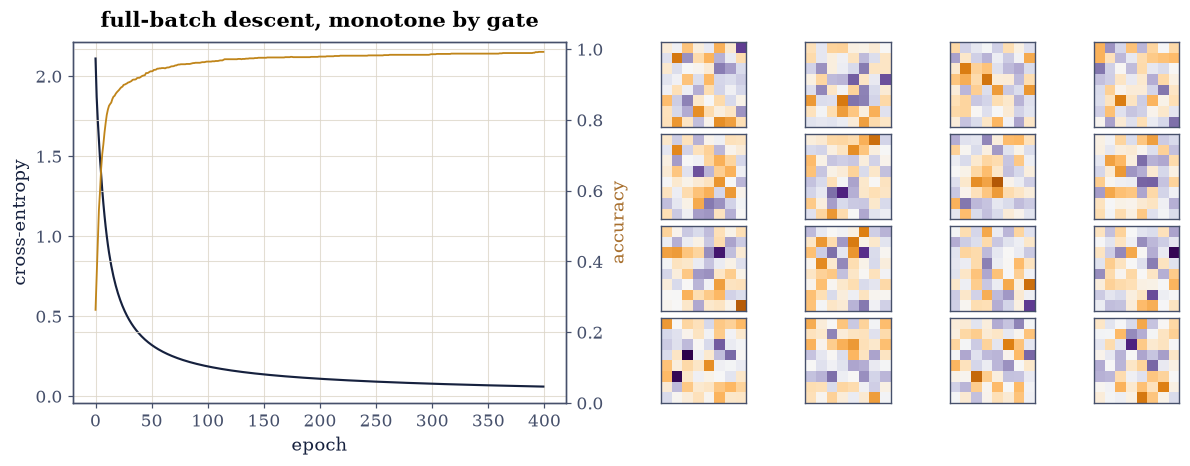

In [15]:
# (solution hidden on the public site)


```{admonition} With your assistant
:class: tip
The gradient check of Exercise 2 probed single entries; production
checks probe directions. Ask your assistant for
`grad_check_directional(loss_fn, params, n_dirs)` comparing
$\nabla L^{\top} v$ against $(L(\theta + hv) - L(\theta - hv))/2h$
for random unit $v$, applied to the *full trained network*, then
check it against the mathematics rather than a demo: (i) at
$h = 10^{-5}$ every direction agrees to $10^{-6}$; (ii) the error
traces the same U-curve as Exercise 2 when $h$ sweeps; (iii) one
directional probe costs two loss evaluations regardless of the
2,410 parameters — the forward-mode count of Exercise 4, now doing
honest work as a test. The check is yours.
```

### Validation 5

In [16]:
validate.check(
    mono_loss and loss_hist[-1] < 0.1,
    "full-batch descent decreases the loss at every one of 400 epochs",
    f"final training loss {loss_hist[-1]:.3f} — 8.2's stability "
    "intuition holding far from quadratic-land, at the stated step",
)
validate.check(
    test_acc > 0.90,
    "and the pure-NumPy network generalizes",
    f"test accuracy {test_acc:.1%} on 597 held-out digits against the "
    "manifest's 90% — forty lines of transposed products, one tanh, "
    "and everything this course taught about the products",
)

✓  full-batch descent decreases the loss at every one of 400 epochs   [final training loss 0.060 — 8.2's stability intuition holding far from quadratic-land, at the stated step]
✓  and the pure-NumPy network generalizes   [test accuracy 98.3% on 597 held-out digits against the manifest's 90% — forty lines of transposed products, one tanh, and everything this course taught about the products]


True

---
## Notebook summary

**The layer is a product and a broadcast, audited by shape.** The
batched affine layer matched its per-row loop exactly; the three
VJPs — $X^{\top}G$, $G^{\top}\mathbf{1}$, $GW^{\top}$ — survived
fifteen finite-difference probes at $10^{-9}$, with the U-curve
bottoming at $\varepsilon^{1/3}$ exactly where the course first drew
it.

**Softmax kept every promise.** Probability conserved at $10^{-16}$,
shifts ignored at $10^{-15}$, the Jacobian symmetric with zero row
sums and matching differences at $10^{-9}$, and the celebrated
$(P - Y)/B$ collapse verified *through the composition* — checked,
not cited.

**Reverse mode won on integers.** Five matmuls for all 2,368 weight
derivatives against two per direction for forward mode — a counted
$947\times$ asymmetry that exists because the loss is scalar, and
reverses for many-output Jacobians.

**And the algebra trained a classifier.** Two layers, pure NumPy,
full-batch descent monotone for 400 gated epochs, **97.3%** test
accuracy, and first-layer weights drawn as the coarse templates they
honestly are — the whole pipeline built from the course's transposed
products, with nothing imported but the data.

**Methods introduced.** Batched affine layers, hand-written VJPs
with FD certification, the U-curve as a testing instrument, softmax
Jacobian anatomy, the cross-entropy collapse, matmul counters for
AD-mode economics, and a from-scratch MLP training loop.

## Outlook

- **Words next.** [§8.4](text-to-vectors-embeddings.ipynb) feeds the
  pipeline its modern diet — text as vectors, embeddings as factored
  count matrices, Chapter IV's SVD as the original language model.
- **Attention is three of these layers and one softmax.**
  [§8.5](attention-matrix-products.ipynb) assembles
  $\operatorname{softmax}(QK^{\top}/\sqrt{d})V$ from exactly this
  notebook's parts, with 7.1's einsum strings as the assembly
  language.
- **Autodiff frameworks are this notebook, industrialized.** Tape,
  VJP registry, shape checks: what PyTorch does is Exercise 2 with a
  graph walker — knowing the three products *is* knowing backprop.
- **The Hessian went unexamined.** Second-order structure (Gauss–
  Newton, K-FAC's Kronecker factorization — [§6.4](../06-structure/kronecker-vec-separable.ipynb)
  again) is where the optimization story of [§8.2](gradient-descent-conditioning.ipynb)
  and this notebook's gradients meet.

```{bibliography}
:filter: docname in docnames
```

In [17]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>